# Single-cell Time Series Interpolation

This notebook runs OT-CFM, SB-CFM and SF2M on the embryoid body data, preprocessed according to the notebooks in `preprocessing`. Here we optimize a single network to model cells over time on the 2D PHATE projection. The same process applies for any other representation. In the paper we compare quantitatively on PCA components and highly variable genes.

Note that to run this notebook you well need the `ebdata_v3.h5ad` data object, which is accessible at https://data.mendeley.com/datasets/hhny5ff7yj/1 along with the other single cell datasets used in this work.

Note that to reproduce the results in the paper, the PC dimensions are taken from this data object https://github.com/KrishnaswamyLab/TrajectoryNet/blob/master/data/eb_velocity_v5.npz, which is not quite the same as the PCs here due to different preprocessing. The highly variable genes were selected with the `sc.pp.highly_variable_genes` function with `n_top_genes=XXX`.

To train the model here we build a batch of all timepoint pairs together. This seems to be the most stable if large batches are affordable.

# 单细胞时间序列插值

本笔记本在类胚体（embryoid body）数据上运行OT-CFM、SB-CFM和SF2M三种模型，数据预处理过程参考`preprocessing`（预处理）文件夹中的笔记本。本文中，我们优化了一个单一网络，用于在二维PHATE投影上对不同时间点的细胞进行建模。该流程同样适用于其他任何数据表征方式。在研究论文中，我们基于主成分分析（PCA）组件和高可变基因（highly variable genes）对模型进行了定量比较。

请注意，运行本笔记本需要`ebdata_v3.h5ad`数据对象，该数据可通过https://data.mendeley.com/datasets/hhny5ff7yj/1 获取，该数据库中还包含本研究使用的其他单细胞数据集。

另请注意，若要复现论文中的结果，需使用来自以下数据对象的PC维度：https://github.com/KrishnaswamyLab/TrajectoryNet/blob/master/data/eb_velocity_v5.npz 。由于预处理流程不同，该数据对象中的PC维度与本文所用数据的PC维度存在差异。高可变基因的筛选则使用`sc.pp.highly_variable_genes`函数（注：`sc`通常指单细胞分析工具包`scanpy`），参数设置为`n_top_genes=XXX`（XXX代表筛选的高可变基因数量，需根据具体实验设定）。

在本文的模型训练中，我们将所有时间点对整合为一个批次（batch）。在硬件支持大批次数据处理的情况下，这种方式被证明是最稳定的训练策略。


### 关键术语补充说明
- **OT-CFM/SB-CFM/SF2M**：均为用于单细胞时间序列分析的计算模型，其中CFM全称为"Conditional Flow Matching"（条件流匹配），OT（Optimal Transport，最优传输）、SB（Score-Based，分数基）为模型设计的核心思路差异，SF2M具体含义需结合原文上下文，推测为一种基于流（Flow）或分数（Score）的改进模型。
- **PHATE投影**：一种用于高维单细胞数据降维可视化的方法，全称为"Potential of Heat-diffusion for Affinity-based Trajectory Embedding"，可有效保留数据的全局结构和轨迹信息。
- **h5ad文件**：单细胞数据分析中常用的数据存储格式，由`anndata`库定义，可同时存储细胞表达矩阵、元数据（如时间点、细胞类型）等信息。

In [1]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import plot_trajectories, torch_wrapper

savedir = "models/single-cell"
os.makedirs(savedir, exist_ok=True)

d:\develop\anaconda\envs\cfm\lib\site-packages\lightning_fabric\__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [2]:
adata = sc.read_h5ad("../data/ebdata_v2.h5ad")
adata

AnnData object with n_obs × n_vars = 8659 × 16245
    obs: 'A1BG (ENSG00000121410)', 'A1BG-AS1 (ENSG00000268895)', 'A2M (ENSG00000175899)', 'A2M-AS1 (ENSG00000245105)', 'A4GALT (ENSG00000128274)', 'AAAS (ENSG00000094914)', 'AACS (ENSG00000081760)', 'AADAT (ENSG00000109576)', 'AAED1 (ENSG00000158122)', 'AAGAB (ENSG00000103591)', 'AAK1 (ENSG00000115977)', 'AAMDC (ENSG00000087884)', 'AAMP (ENSG00000127837)', 'AANAT (ENSG00000129673)', 'AAR2 (ENSG00000131043)', 'AARD (ENSG00000205002)', 'AARS (ENSG00000090861)', 'AARS2 (ENSG00000124608)', 'AARSD1 (ENSG00000266967)', 'AASDH (ENSG00000157426)', 'AASDHPPT (ENSG00000149313)', 'AASS (ENSG00000008311)', 'AATF (ENSG00000275700)', 'AATK (ENSG00000181409)', 'ABAT (ENSG00000183044)', 'ABCA1 (ENSG00000165029)', 'ABCA2 (ENSG00000107331)', 'ABCA3 (ENSG00000167972)', 'ABCA5 (ENSG00000154265)', 'ABCA7 (ENSG00000064687)', 'ABCA8 (ENSG00000141338)', 'ABCA9 (ENSG00000154258)', 'ABCB10 (ENSG00000135776)', 'ABCB4 (ENSG00000005471)', 'ABCB5 (ENSG00000004846)',

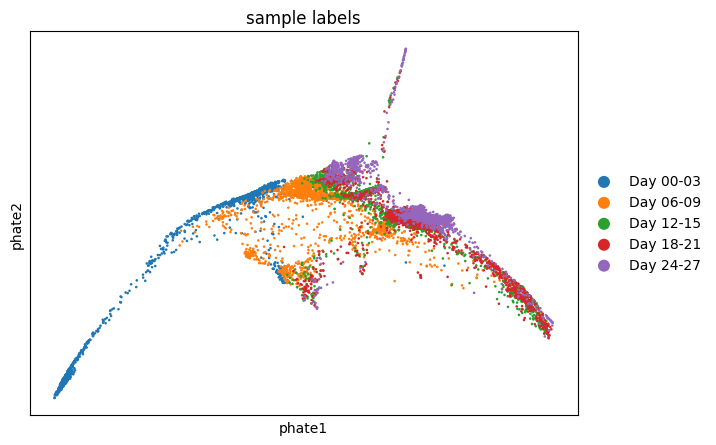

In [3]:
sc.pl.scatter(adata, basis="phate", color="sample_labels")

In [4]:
n_times = len(adata.obs["sample_labels"].unique())
# Standardize coordinates
coords = adata.obsm["X_phate"]
coords = (coords - coords.mean(axis=0)) / coords.std(axis=0)
adata.obsm["X_phate_standardized"] = coords
X = [
    adata.obsm["X_phate_standardized"][adata.obs["sample_labels"].cat.codes == t]
    for t in range(n_times)
]

In [5]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 256
sigma = 0.1
dim = 2
ot_cfm_model = MLP(dim=dim, time_varying=True, w=64).to(device)
ot_cfm_optimizer = torch.optim.Adam(ot_cfm_model.parameters(), 1e-4)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)

In [6]:
import scprep


def plot_trajectories(traj, legend=True):
    n = 2000
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    scprep.plot.scatter(
        adata.obsm["X_phate_standardized"][:, 0],
        adata.obsm["X_phate_standardized"][:, 1],
        c=adata.obs["sample_labels"],
        ax=ax,
    )
    # ax.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    ax.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    # ax.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(15):
        ax.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    # plt.xticks([])
    # plt.yticks([])
    # plt.axis("off")


def get_batch(FM, X, batch_size, n_times, return_noise=False):
    """Construct a batch with point sfrom each timepoint pair"""
    ts = []
    xts = []
    uts = []
    noises = []
    for t_start in range(n_times - 1):
        x0 = (
            torch.from_numpy(X[t_start][np.random.randint(X[t_start].shape[0], size=batch_size)])
            .float()
            .to(device)
        )
        x1 = (
            torch.from_numpy(
                X[t_start + 1][np.random.randint(X[t_start + 1].shape[0], size=batch_size)]
            )
            .float()
            .to(device)
        )
        if return_noise:
            t, xt, ut, eps = FM.sample_location_and_conditional_flow(
                x0, x1, return_noise=return_noise
            )
            noises.append(eps)
        else:
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1, return_noise=return_noise)
        ts.append(t + t_start)
        xts.append(xt)
        uts.append(ut)
    t = torch.cat(ts)
    xt = torch.cat(xts)
    ut = torch.cat(uts)
    if return_noise:
        noises = torch.cat(noises)
        return t, xt, ut, noises
    return t, xt, ut

## OT-CFM
最优传输流匹配

In [7]:
for i in tqdm(range(10000)):
    ot_cfm_optimizer.zero_grad()
    t, xt, ut = get_batch(FM, X, batch_size, n_times)
    vt = ot_cfm_model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)
    loss.backward()
    ot_cfm_optimizer.step()

100%|██████████| 10000/10000 [05:04<00:00, 32.83it/s]


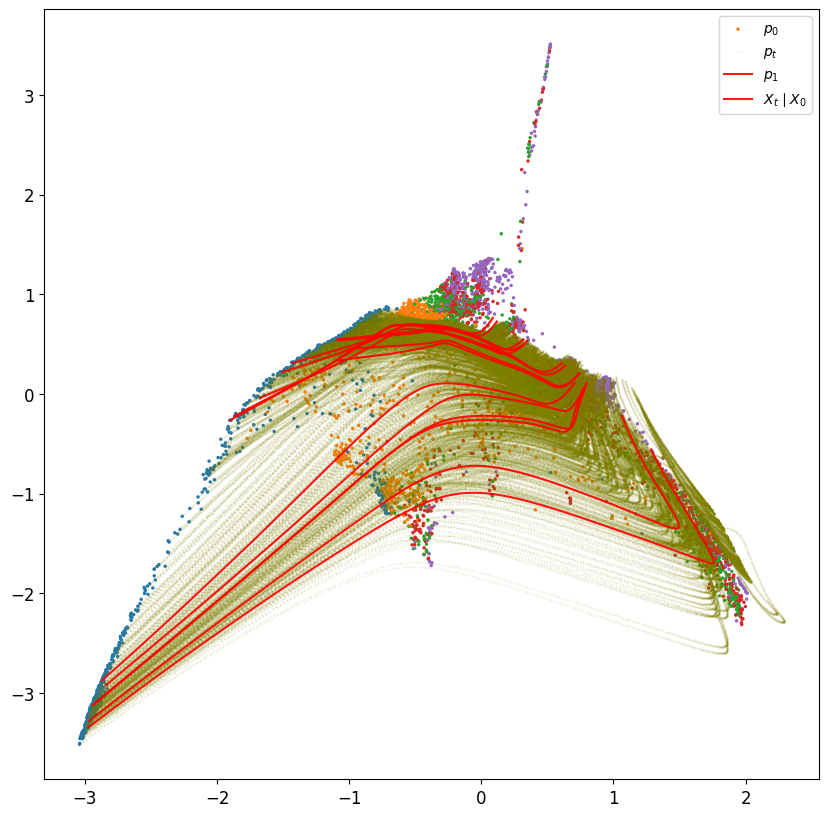

In [8]:
node = NeuralODE(torch_wrapper(ot_cfm_model), solver="dopri5", sensitivity="adjoint")
with torch.no_grad():
    traj = node.trajectory(
        torch.from_numpy(X[0][:1000]).float().to(device),
        t_span=torch.linspace(0, n_times - 1, 400),
    ).cpu()
    plot_trajectories(traj.cpu().numpy())

In [9]:
torch.save(
    {
        "model": ot_cfm_model,
        "optimizer": ot_cfm_optimizer,
    },
    f"{savedir}/ot_cfm_single_cell.pt",
)

## SF2M
薛定谔桥条件流匹配

In [10]:
sigma = 0.25
sf2m_model = MLP(dim=dim, time_varying=True, w=64).to(device)
sf2m_score_model = MLP(dim=dim, time_varying=True, w=64).to(device)
sf2m_optimizer = torch.optim.AdamW(
    list(sf2m_model.parameters()) + list(sf2m_score_model.parameters()), 1e-4
)
SF2M = SchrodingerBridgeConditionalFlowMatcher(sigma=sigma)

In [11]:
max_norm_ut = torch.tensor(0.0)
for i in tqdm(range(10000)):
    sf2m_optimizer.zero_grad()
    t, xt, ut, eps = get_batch(SF2M, X, batch_size, n_times, return_noise=True)
    lambda_t = SF2M.compute_lambda(t % 1)
    vt = sf2m_model(torch.cat([xt, t[:, None]], dim=-1))
    st = sf2m_score_model(torch.cat([xt, t[:, None]], dim=-1))
    flow_loss = torch.mean((vt - ut) ** 2)
    # max_norm_ut = torch.maximum(torch.max(torch.sum(ut**2, dim=1)), max_norm_ut)
    score_loss = torch.mean((lambda_t[:, None] * st + eps) ** 2)
    if i % 1000 == 0:
        # print(max_norm_ut)
        
        print(f"iteration:{i}: flow_loss:{flow_loss.item():0.2f}, score_loss:{score_loss.item():0.2f}")
    loss = flow_loss + score_loss

    loss.backward()
    sf2m_optimizer.step()

  0%|          | 3/10000 [00:00<05:48, 28.65it/s]

iteration:0: flow_loss:1.06, score_loss:1.30


 10%|█         | 1003/10000 [00:37<04:41, 31.91it/s]

iteration:1000: flow_loss:0.31, score_loss:0.83


 20%|██        | 2005/10000 [01:09<04:49, 27.61it/s]

...

 80%|████████  | 8004/10000 [05:21<01:47, 18.64it/s]

iteration:8000: flow_loss:0.36, score_loss:0.74


 90%|█████████ | 9003/10000 [06:00<00:30, 32.99it/s]

iteration:9000: flow_loss:0.35, score_loss:0.73


100%|██████████| 10000/10000 [06:31<00:00, 25.54it/s]


In [12]:
node = NeuralODE(torch_wrapper(sf2m_model), solver="euler", sensitivity="adjoint")
x0 = torch.from_numpy(X[0][:1000]).float()
with torch.no_grad():
    traj = node.trajectory(
        x0.to(device),
        t_span=torch.linspace(0, n_times - 1, 400, device=device),
    ).cpu()

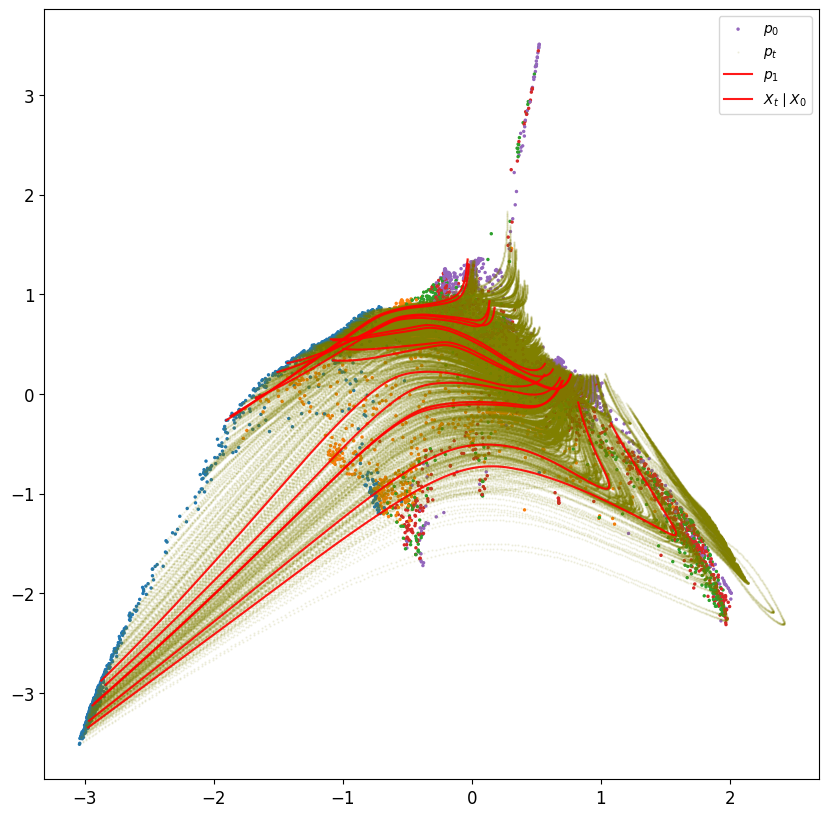

In [13]:
plot_trajectories(traj.cpu().numpy())

In [14]:
class SDE(torch.nn.Module):
    noise_type = "diagonal"
    sde_type = "ito"

    def __init__(self, ode_drift, score, input_size=(3, 32, 32), sigma=1.0):
        super().__init__()
        self.drift = ode_drift
        self.score = score
        self.input_size = input_size
        self.sigma = sigma

    # Drift
    def f(self, t, y):
        y = y.view(-1, *self.input_size)
        if len(t.shape) == len(y.shape):
            x = torch.cat([y, t], 1)
        else:
            x = torch.cat([y, t.repeat(y.shape[0])[:, None]], 1)
        return self.drift(x).flatten(start_dim=1) + self.score(x).flatten(start_dim=1)

    # Diffusion
    def g(self, t, y):
        return torch.ones_like(y) * self.sigma


sde = SDE(sf2m_model, sf2m_score_model, input_size=(2,), sigma=sigma)
with torch.no_grad():
    sde_traj = torchsde.sdeint(
        sde,
        x0.to(device),
        ts=torch.linspace(0, n_times - 1, 400, device=device),
    ).cpu()

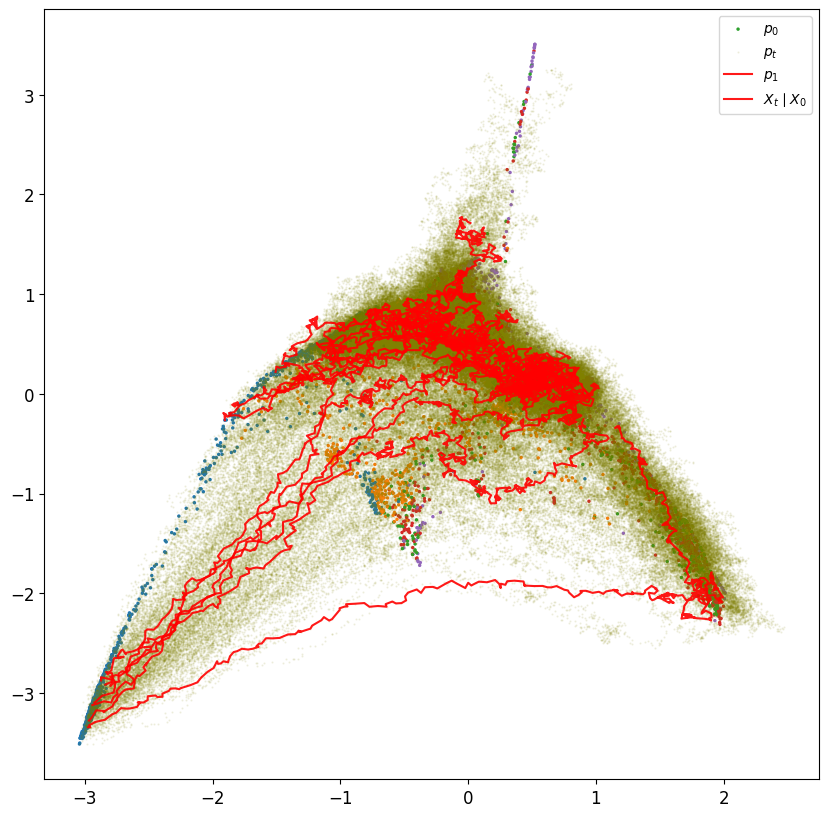

In [15]:
plot_trajectories(sde_traj.detach().cpu().numpy())

In [16]:
torch.save(
    {
        "model": sf2m_model,
        "score_model": sf2m_score_model,
        "optimizer": sf2m_optimizer,
    },
    f"{savedir}/sf2m_single_cell_sigma_{sigma}.pt",
)

# Evolution of trajectories between SF2M's probability flow ODE (SB-CFM) and SF2M

SB-CFM 与 SF2M 的轨迹演化
SB-CFM的轨迹是决定性的, 而SF2M是通过随机微分方程求解的

## Starting from a cell at day 0

In [17]:
node = NeuralODE(torch_wrapper(sf2m_model), solver="euler", sensitivity="adjoint")
x0 = torch.from_numpy(X[0][:1000]).float()
with torch.no_grad():
    traj = node.trajectory(
        x0[2].repeat(20).view(20, 2).to(device),
        t_span=torch.linspace(0, n_times - 1, 400, device=device),
    ).cpu()
# plot_trajectories(traj.cpu().numpy())

In [18]:
with torch.no_grad():
    sde_traj = torchsde.sdeint(
        sde,
        x0[2].repeat(20).view(20, 2).to(device),
        ts=torch.linspace(0, n_times - 1, 400, device=device),
    ).cpu()

In [19]:
traj = traj.detach().cpu().numpy()
sde_traj = sde_traj.detach().cpu().numpy()

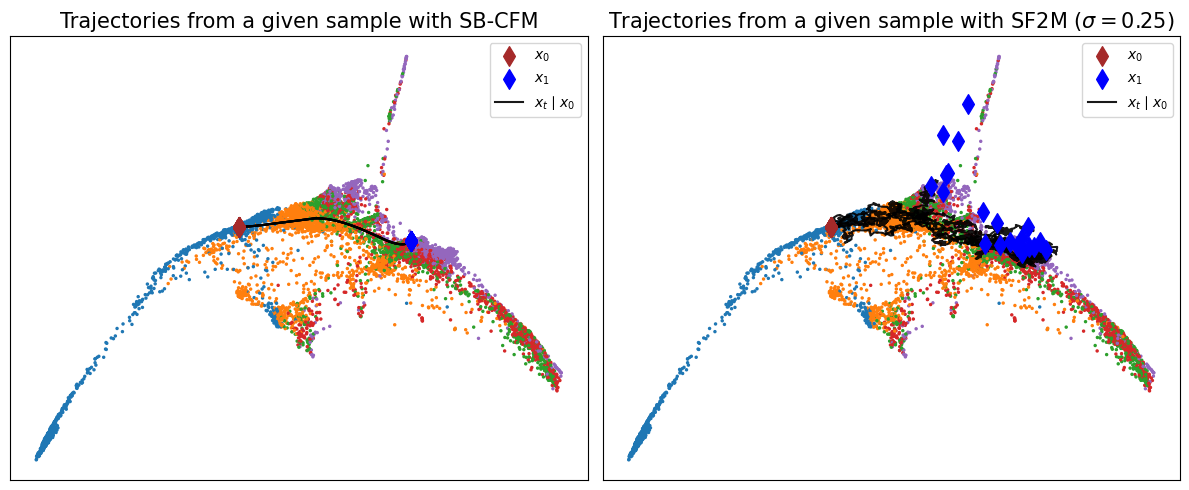

In [20]:
n = 2000
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(traj[0, :n, 0], traj[0, :n, 1], s=100, alpha=1, marker="d", c="brown", zorder=3)
ax1.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=100, alpha=1, marker="d", c="blue", zorder=3)

for i in range(5):
    ax1.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="black", zorder=2)

scprep.plot.scatter(
    adata.obsm["X_phate_standardized"][:, 0],
    adata.obsm["X_phate_standardized"][:, 1],
    c=adata.obs["sample_labels"],
    ax=ax1,
    legend=None,
)

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title("Trajectories from a given sample with SB-CFM", fontsize=15)
ax1.legend([r"$x_0$", r"$x_1$", r"$x_t \mid x_0$"])


ax2.scatter(
    sde_traj[0, :n, 0], sde_traj[0, :n, 1], s=100, alpha=1, marker="d", c="brown", zorder=3
)
ax2.scatter(
    sde_traj[-1, :n, 0], sde_traj[-1, :n, 1], s=100, alpha=1, marker="d", c="blue", zorder=3
)

for i in range(5):
    ax2.plot(sde_traj[:, i, 0], sde_traj[:, i, 1], alpha=0.9, c="black", zorder=2)

scprep.plot.scatter(
    adata.obsm["X_phate_standardized"][:, 0],
    adata.obsm["X_phate_standardized"][:, 1],
    c=adata.obs["sample_labels"],
    ax=ax2,
    legend=None,
)

ax2.legend([r"$x_0$", r"$x_1$", r"$x_t \mid x_0$"])

ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title(
    r"Trajectories from a given sample with SF2M $(\sigma={})$".format(sigma), fontsize=15
)

plt.tight_layout()
plt.savefig("conditonal_trajectory_sf2m_sigma_{}.png".format(sigma))

## Starting from a cell at an older time (day 25)

In [21]:
len(X)

5

In [22]:
node = NeuralODE(torch_wrapper(sf2m_model), solver="euler", sensitivity="adjoint")
x0 = torch.from_numpy(X[1][:1000]).float()
with torch.no_grad():
    traj = node.trajectory(
        x0[1].repeat(15).view(15, 2).to(device),
        t_span=torch.linspace(1, n_times - 1, 300, device=device),
    ).cpu()

with torch.no_grad():
    sde_traj = torchsde.sdeint(
        sde,
        x0[1].repeat(15).view(15, 2).to(device),
        ts=torch.linspace(1, n_times - 1, 300, device=device),
    ).cpu()

traj = traj.detach().cpu().numpy()

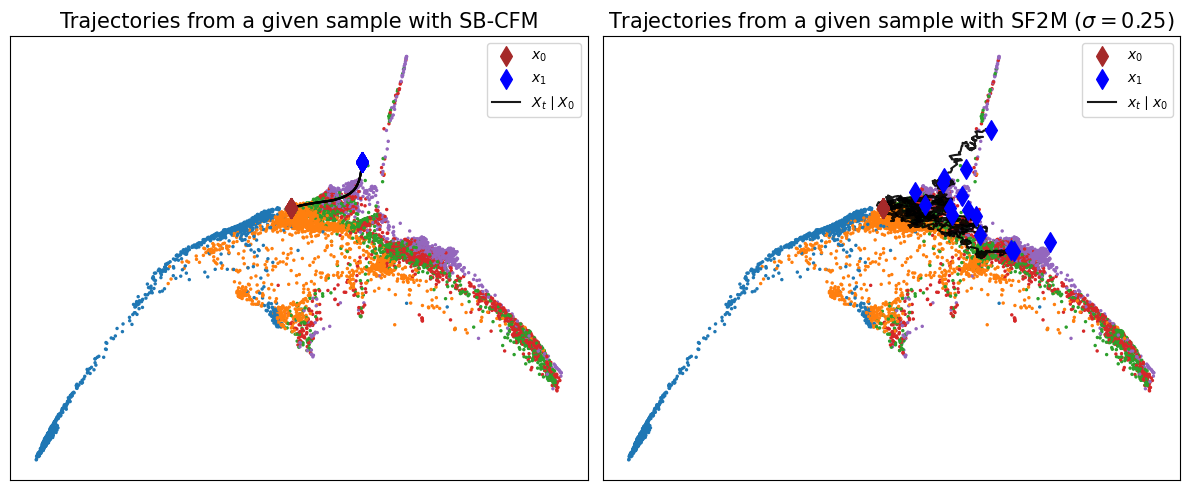

In [23]:
n = 2000
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


ax1.scatter(traj[0, :n, 0], traj[0, :n, 1], s=100, alpha=1, marker="d", c="brown", zorder=3)
ax1.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=100, alpha=1, marker="d", c="blue", zorder=3)

for i in range(5):
    ax1.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="black", zorder=2)

scprep.plot.scatter(
    adata.obsm["X_phate_standardized"][:, 0],
    adata.obsm["X_phate_standardized"][:, 1],
    c=adata.obs["sample_labels"],
    ax=ax1,
    legend=None,
)

ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_title("Trajectories from a given sample with SB-CFM", fontsize=15)
ax1.legend([r"$x_0$", r"$x_1$", r"$X_t \mid X_0$"])


ax2.scatter(
    sde_traj[0, :n, 0], sde_traj[0, :n, 1], s=100, alpha=1, marker="d", c="brown", zorder=3
)
ax2.scatter(
    sde_traj[-1, :n, 0], sde_traj[-1, :n, 1], s=100, alpha=1, marker="d", c="blue", zorder=3
)

for i in range(5):
    ax2.plot(sde_traj[:, i, 0], sde_traj[:, i, 1], alpha=0.9, c="black", zorder=2)


scprep.plot.scatter(
    adata.obsm["X_phate_standardized"][:, 0],
    adata.obsm["X_phate_standardized"][:, 1],
    c=adata.obs["sample_labels"],
    ax=ax2,
    legend=None,
)

ax2.legend([r"$x_0$", r"$x_1$", r"$x_t \mid x_0$"])

ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title(
    r"Trajectories from a given sample with SF2M $(\sigma={})$".format(sigma), fontsize=15
)
# plt.axis("off")

plt.tight_layout()
plt.savefig("conditonal_trajectory_sf2m_sigma_{}_from_later_time.png".format(sigma))

### As SB-CFM is a deterministic process, it only ends up at one final location contrary to our model SF2M that models a stochastic process and produces different outputs.

由于 SB-CFM 是一个确定性过程，它最终只会到达一个固定的终点；而我们的模型 SF2M 则不同，它对随机过程进行建模，因此能产生多种不同的输出结果